# 02. Feature Engineering

**Proyecto**: Pronóstico de demanda multi-series (Curso II — Especialización ML Engineering)

En este notebook se convierte el dataset (store, item, date, sales) en un dataset
**supervisado de regresión** agregando:

- **Features de calendario**: `year`, `month`, `day`, `dayofweek`, `weekofyear`, `dayofyear`.
- **Lags** del target: ventas de hace 1, 7 y 30 días (`lag_1`, `lag_7`, `lag_30`).
- **Estadísticas móviles** por serie: media y desviación de la última semana y del último mes.

> Importante: lags y rolling usan `shift(1)` (solo valores pasados) para **no fugarse
> información del día que se predice**.

El módulo reutilizable vive en `src/features/build_features.py` y este notebook solo lo usa.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.features.build_features import build_features, FEATURE_COLUMNS

sns.set_theme()
pd.set_option("display.float_format", "{:.2f}".format)

PROCESSED = Path("../data/processed")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
print("OK")

OK


## 1. Carga de datos procesados

In [2]:
train = pd.read_csv(PROCESSED / "train.csv", parse_dates=["date"])
holdout = pd.read_csv(PROCESSED / "holdout.csv", parse_dates=["date"])
print(f"train: {train.shape[0]:,} filas | holdout: {holdout.shape[0]:,} filas")
train.head()

train: 867,000 filas | holdout: 46,000 filas


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 2. Construcción de features

In [3]:
train_feat = build_features(train)
train_feat.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,2,13.00,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,3,11.00,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,4,14.00,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,5,13.00,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(f"Columnas nuevas: {set(train_feat.columns) - set(train.columns)}")
print(f"Nuevas dimensiones: {train_feat.shape}")

Columnas nuevas: {'rolling_mean_30', 'year', 'dayofweek', 'rolling_std_30', 'day', 'lag_30', 'lag_7', 'rolling_mean_7', 'dayofyear', 'weekofyear', 'lag_1', 'rolling_std_7', 'month'}
Nuevas dimensiones: (867000, 17)


## 3. Manejo de valores nulos (lags y rolling)

In [5]:
# Los lags/rolling generan NaN en las primeras filas de cada serie (no hay historial).
nulls = train_feat.isna().sum()
null_cols = nulls[nulls > 0]
print(null_cols.to_string())
print(f"\nFilas sin NaN (útiles para entrenar): {train_feat.dropna().shape[0]:,} de {len(train_feat):,} ({train_feat.dropna().shape[0]/len(train_feat)*100:.1f}%)")

lag_1                500
lag_7               3500
lag_30             15000
rolling_mean_7      3500
rolling_std_7       3500
rolling_mean_30    15000
rolling_std_30     15000

Filas sin NaN (útiles para entrenar): 852,000 de 867,000 (98.3%)


In [6]:
train_feat_clean = train_feat.dropna().copy()
print(f"Filas finales para modelar: {len(train_feat_clean):,}")
print("Series representadas:", train_feat_clean.groupby(['store','item']).ngroups)

Filas finales para modelar: 852,000
Series representadas: 500


## 4. Distribución y correlación de features

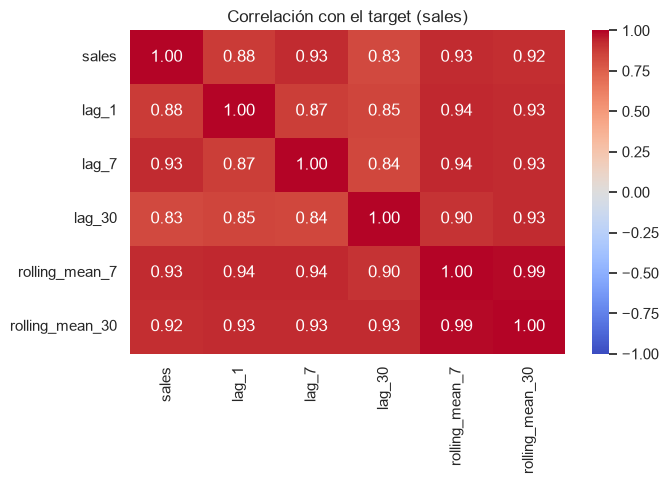

In [7]:
corr = train_feat_clean[["sales", "lag_1", "lag_7", "lag_30", "rolling_mean_7", "rolling_mean_30"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación con el target (sales)")
plt.tight_layout(); plt.savefig(FIGURES / "correlacion_features.png", dpi=150); plt.show()

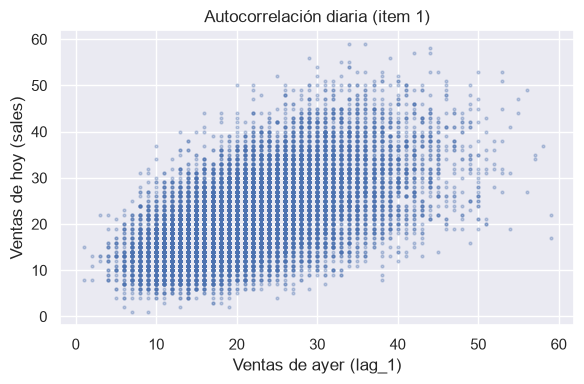

In [8]:
# Relación lag_1 vs ventas reales (muestra de 5 series)
sample = train_feat_clean[train_feat_clean["item"] == 1]
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample["lag_1"], sample["sales"], s=4, alpha=0.3)
ax.set_xlabel("Ventas de ayer (lag_1)")
ax.set_ylabel("Ventas de hoy (sales)")
ax.set_title("Autocorrelación diaria (item 1)")
fig.tight_layout(); fig.savefig(FIGURES / "scatter_lag1.png", dpi=150); plt.show()

## 5. Aplicación al holdout y guardado

In [9]:
holdout_feat = build_features(holdout)
holdout_feat_clean = holdout_feat.dropna().copy()
print(f"holdout con features: {len(holdout_feat_clean):,} filas")
print(f"Rango de fechas: {holdout_feat_clean['date'].min().date()} a {holdout_feat_clean['date'].max().date()}")

holdout con features: 31,000 filas
Rango de fechas: 2017-10-31 a 2017-12-31


In [10]:
train_feat_clean.to_csv(PROCESSED / "train_features.csv", index=False)
holdout_feat_clean.to_csv(PROCESSED / "holdout_features.csv", index=False)
print("Guardado: data/processed/train_features.csv y holdout_features.csv")

Guardado: data/processed/train_features.csv y holdout_features.csv


## Conclusiones

- Se convirtió el dataset en un problema supervisado con 11 features por fila.
- Se descartan las primeras observaciones de cada serie (sin historial para lags/rolling).
- `lag_1`, `rolling_mean_7` y `rolling_mean_30` tienen la correlación más alta con el target.
- Los datos listos para modelar quedan en `data/processed/*_features.csv`; las columnas
  `store` y `item` se usarán como categóricas en los modelos de gradiente boosting.